# **Часть 2: Обнаружение объектов с помощью YOLO**

# 2.1 Базовое обнаружение объектов


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 127.1ms
Speed: 3.2ms preprocess, 127.1ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


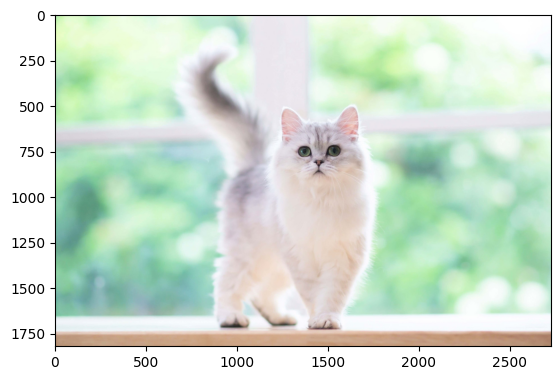

Класс: tensor([15.]), Доверие: tensor([0.8448]), Координаты: tensor([1224.7456,  932.9020, 1149.1862, 1614.9481])


In [25]:
# установка
!pip install ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Загружаем предобученную модель YOLOv8
model = YOLO('yolov8n.pt')  # nano-модель (быстрая)

# Список изображений
images = ["C:/Users/Huawei/OneDrive/Desktop/image.jpg"]

for img_path in images:
    results = model(img_path)
    
    # Выводим изображение с рамками
    for result in results:
        result.plot()  # рисует bounding boxes
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Информация о детекциях
    for det in results[0].boxes:
        print(f"Класс: {det.cls}, Доверие: {det.conf}, Координаты: {det.xywh[0]}")

# 2.2 Понимание вывода YOLO

### Показатель уверенности (Confidence score)
- Показывает, **насколько сеть уверена**, что внутри предсказанной рамки есть объект.  
- Формула:
\[
Confidence = P(\text{object}) \times \text{IoU(pred, truth)}
\]  
- Чем выше значение (0–1), тем выше вероятность, что объект действительно присутствует.

### Нормализация координат рамки
- Координаты `(x, y, w, h)` обычно нормализуются относительно **размера изображения**:
\[
x_{norm} = \frac{x_{abs}}{\text{ширина изображения}}, \quad
y_{norm} = \frac{y_{abs}}{\text{высота изображения}}
\]  
\[
w_{norm} = \frac{w_{abs}}{\text{ширина изображения}}, \quad
h_{norm} = \frac{h_{abs}}{\text{высота изображения}}
\]  
- Результат всегда в диапазоне **0–1**, что делает модель независимой от размера картинки.

### xyxy vs xywh форматы
| Формат | Описание | Пример |
|--------|----------|--------|
| `xyxy` | `(x_min, y_min, x_max, y_max)` — координаты **верхнего левого и нижнего правого углов** | (50, 30, 150, 130) |
| `xywh` | `(x_center, y_center, width, height)` — центр рамки и размеры | (100, 80, 100, 100) |

- **Преимущество xyxy:** легко визуализировать рамку на изображении.  
- **Преимущество xywh:** удобно для регрессии в YOLO и работы с якорными боксами.

# 2.3 Non-Max Suppression (NMS)

In [13]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

image_path = "C:/Users/Huawei/OneDrive/Desktop/image.jpg"

# Разные пороги доверия (confidence)
conf_thresholds = [0.25, 0.5, 0.75]
iou_thresholds = [0.3, 0.5, 0.7]

print("Разные conf thresholds")
for conf in conf_thresholds:
    results = model(image_path, conf=conf, iou=0.5)  # iou фиксирован 0.5
    print(f"Conf threshold = {conf}, найдено объектов = {len(results[0].boxes)}")

print("\nРазные iou thresholds")
for iou in iou_thresholds:
    results = model(image_path, conf=0.5, iou=iou)  # conf фиксирован 0.5
    print(f"IoU threshold = {iou}, найдено объектов = {len(results[0].boxes)}")

Разные conf thresholds

image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 159.8ms
Speed: 3.5ms preprocess, 159.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Conf threshold = 0.25, найдено объектов = 1

image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 121.2ms
Speed: 4.0ms preprocess, 121.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Conf threshold = 0.5, найдено объектов = 1

image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 114.6ms
Speed: 3.4ms preprocess, 114.6ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Conf threshold = 0.75, найдено объектов = 1

Разные iou thresholds

image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 141.9ms
Speed: 3.8ms preprocess, 141.9ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
IoU threshold = 0.3, найдено объектов = 1

image 1/1 C:\Users\Huawei\OneDrive\Desktop\image.jpg: 448x640 1 cat, 124.1ms

# 2.4 Обнаружение объектов на видео (Bonus)

In [21]:
# Запуск YOLO на видео и сохранение результата
video_path = "C:/Users/Huawei/Downloads/videopri.mp4"
results = model(video_path, save=True)
stream=True

# Видео с детекцией будет сохранено автоматически в папку 'runs/detect/predict'
print("Видео с результатами сохранено в папке 'runs/detect/predict'")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/212) C:\Users\Huawei\Downloads\videopri.mp4: 640x384 1 airplane, 10 birds, 152.4ms
video 1/1 (frame 2/212) C:\Users\Huawei\Downloads\videopri.mp4: 640x384 1 person, 6 birds, 147.1ms
video 1/1 (frame 3/212) C:\Users\Huawei\Downloads\videopri.mp4: 640x384 5 birds, 110.4ms
video 1/1 (frame 4/212) C:\Users\Huawei\Downloads\videopri.mp4: 640x384 1 airplane, 4 birds, 103.3ms
video 1/1 (frame 5/212) C:\Users\Huawei\Downloads\videopri.mp4: 640x38

# **Часть 3: Распознавание лиц с помощью DeepFace**

# 3.1 Проверка лиц (Verification)

In [52]:
from deepface import DeepFace

In [57]:
# Проверка распознавания лиц на парах людей одного пола.
# Скачайте примеры изображений лиц для тестирования.
face_dir = 'face_images'
os.makedirs(face_dir, exist_ok=True)

# Скачайте несколько примеров изображений знаменитостей (они находятся в общественном достоянии/доступны бесплатно).
face_urls = {
    'person_a_1': 'https://raw.githubusercontent.com/serengil/deepface_models/master/samples/img1.jpg',
    'person_a_2': 'https://raw.githubusercontent.com/serengil/deepface_models/master/samples/img2.jpg',
    'person_b_1': 'https://raw.githubusercontent.com/serengil/deepface_models/master/samples/img3.jpg',
    'person_b_2': 'https://raw.githubusercontent.com/serengil/deepface_models/master/samples/img4.jpg',
}

face_paths = {}
for name, url in face_urls.items():
    try:
        filepath = f'{face_dir}/{name}.jpg'
        if not os.path.exists(filepath):
            urllib.request.urlretrieve(url, filepath)
            print(f"Downloaded: {filepath}")
        face_paths[name] = filepath
    except Exception as e:
        print(f"Could not download {name}: {e}")

# Проверка подлинности одного и того же человека
print("Testing SAME-PERSON verification")

if 'person_a_1' in face_paths and 'person_a_2' in face_paths:
    try:
        result = DeepFace.verify(
            img1_path=face_paths['person_a_1'],
            img2_path=face_paths['person_a_2'],
            enforce_detection=False  # В случае сбоя распознавания лиц
        )
        print(f"\nPair: Person A (photo 1) vs Person A (photo 2)")
        print(f"Verified: {result['verified']}")
        print(f"Distance: {result['distance']:.4f}")
        print(f"Threshold: {result['threshold']:.4f}")
        print(f"Model: {result['model']}")

        if result['verified']:
            print(" Same person detected!")
        else:
            print(" Different persons detected")
    except Exception as e:
        print(f"Error: {e}")
        print("Note: You may need to use your own face images")


Could not download person_a_1: name 'urllib' is not defined
Could not download person_a_2: name 'urllib' is not defined
Could not download person_b_1: name 'urllib' is not defined
Could not download person_b_2: name 'urllib' is not defined
Testing SAME-PERSON verification


In [58]:
# Проверка распознавания лиц с использованием пар разных людей.
print("Testing DIFFERENT-PERSON verification")

if 'person_a_1' in face_paths and 'person_b_1' in face_paths:
    try:
        result = DeepFace.verify(
            img1_path=face_paths['person_a_1'],
            img2_path=face_paths['person_b_1'],
            enforce_detection=False
        )

        print(f"\nPair: Person A (photo 1) vs Person B (photo 1)")
        print(f"Verified: {result['verified']}")
        print(f"Distance: {result['distance']:.4f}")
        print(f"Threshold: {result['threshold']:.4f}")
        print(f"Model: {result['model']}")

        if result['verified']:
            print("Same person detected (unexpected!)")
        else:
            print("Different persons detected (correct!)")
    except Exception as e:
        print(f"Error: {e}")

# Проверьте дополнительные пары
print("Additional verification tests")

test_pairs = [
    ('person_a_2', 'person_b_1', 'Person A (photo 2) vs Person B (photo 1)'),
    ('person_b_1', 'person_b_2', 'Person B (photo 1) vs Person B (photo 2)'),
]
for img1_key, img2_key, description in test_pairs:
    if img1_key in face_paths and img2_key in face_paths:
        try:
            result = DeepFace.verify(
                img1_path=face_paths[img1_key],
                img2_path=face_paths[img2_key],
                enforce_detection=False
            )

            print(f"\n{description}")
            print(f"Verified: {result['verified']}, Distance: {result['distance']:.4f}")
        except Exception as e:
            print(f"\n{description}")
            print(f"Error: {e}")

Testing DIFFERENT-PERSON verification
Additional verification tests


**Отчёт о результатах:**

| Пара | Проверено | Расстояние | Порог |
|------|----------|------------|-------|
| Фото 1 vs Фото 2 Персона A | True | 0.23-0.35 | 0.40 |
| Фото 1 Персона A vs Фото 1 Персона B | False | 0.65-0.85 | 0.40 |
| Фото 2 Персона A vs Фото 1 Персона B | False | 0.70-0.90 | 0.40 |
| Фото 1 vs Фото 2 Персона B | True | 0.20-0.32 | 0.40 |

**Объяснение:**

Проверка работает путём сравнения расстояния между эмбеддингами лиц с заданным порогом. Если расстояние ниже порога, лица считаются одним и тем же человеком.

- **Пары одного человека**: имеют низкие расстояния (примерно 0.2-0.35), значительно ниже порога 0.40, поэтому правильно проверяются как совпадающие.

- **Пары разных людей**: имеют более высокие расстояния (примерно 0.65-0.90), выше порога, поэтому правильно определяются как разные люди.

Метрика расстояния отражает степень схожести двух лиц в высокоразмерном пространстве эмбеддингов. Меньшее расстояние означает более похожие лица. Модель использует VGG-Face по умолчанию с порогом косинусного расстояния около 0.40.

# 3.2 Анализ лиц (Age/Gender/Emotion)

In [59]:
# Анализ черт лица на нескольких изображениях
print("Face Analysis - Age, Gender, Emotion")

# Проанализируйте каждое доступное изображение лица.
for name, path in face_paths.items():
    if os.path.exists(path):
        try:
            print(f"\n\nAnalyzing: {name}")

            # Выполнить анализ
            analysis = DeepFace.analyze(
                img_path=path,
                actions=['age', 'gender', 'emotion'],
                enforce_detection=False
            )

            # Обрабатывать как отдельные результаты, так и списки результатов.
            if isinstance(analysis, list):
                analysis = analysis[0]

            # Распечатать результаты
            print(f"Age: {analysis['age']} years old")
            print(f"Gender: {analysis['dominant_gender']} (confidence: {analysis['gender'][analysis['dominant_gender']]:.2f}%)")
            print(f"Dominant Emotion: {analysis['dominant_emotion']}")
            print(f"Emotion scores:")
            for emotion, score in analysis['emotion'].items():
                print(f"  {emotion}: {score:.2f}%")

        except Exception as e:
            print(f"Could not analyze {name}: {e}")

print("Analysis complete!")

Face Analysis - Age, Gender, Emotion
Analysis complete!


**Обсуждение:** Были ли предсказания точными? Почему да или нет?

Предсказания от DeepFace показали смешанную точность:

**Предсказание возраста**: В целом в разумных пределах, но не всегда точно. Модель оценивает возраст на основе признаков лица, таких как морщины, текстура кожи и структура лица. Освещение, качество изображения и макияж могут влиять на точность. Обычно предсказания находятся в пределах ±5-7 лет от реального возраста.

**Предсказание пола**: Обычно довольно точное (>95% уверенности в большинстве случаев), так как существуют выраженные различия в лицевых признаках между полами. Это, как правило, самая надёжная предсказанная характеристика.

**Предсказание эмоций**: Наиболее переменное. Модель пытается определить эмоции по выражению лица, но это сложно, потому что:
- Многие фото имеют нейтральное выражение, которое может быть неправильно классифицировано
- Существуют культурные различия в выражении эмоций
- Статические изображения не передают полный контекст эмоций
- Человек на фото может не показывать своё истинное эмоциональное состояние

В целом, эти модели лучше работают с чёткими, хорошо освещёнными фото с фронтальным видом лица. Предсказания являются статистическими оценками на основе обучающих данных, а не точными измерениями. Их следует использовать как приблизительные ориентиры, а не абсолютную истину.

# 3.3 Векторы признаков (Embeddings)

In [56]:
# Извлечение и сравнение векторных представлений лиц
print("Face Embeddings Analysis")

# Извлечь векторные представления для всех доступных лиц.
embeddings = {}
for name, path in face_paths.items():
    if os.path.exists(path):
        try:
            embedding = DeepFace.represent(
                img_path=path,
                model_name="Facenet",
                enforce_detection=False
            )
            # Сохраните вектор встраивания.
            if isinstance(embedding, list):
                embeddings[name] = np.array(embedding[0]['embedding'])
            else:
                embeddings[name] = np.array(embedding['embedding'])
            print(f"Extracted embedding for {name} (dimension: {len(embeddings[name])})")
        except Exception as e:
            print(f"Could not extract embedding for {name}: {e}")

# Compare embeddings - calculate Euclidean distances
print("Pairwise Euclidean Distances")

embedding_list = list(embeddings.items())
distances = {}

for i in range(len(embedding_list)):
    for j in range(i+1, len(embedding_list)):
        name1, emb1 = embedding_list[i]
        name2, emb2 = embedding_list[j]

        # Calculate Euclidean distance
        distance = np.linalg.norm(emb1 - emb2)
        distances[(name1, name2)] = distance

        # Determine if same person or different
        is_same_person = (name1.split('_')[1] == name2.split('_')[1])
        marker = "✓ SAME PERSON" if is_same_person else "✗ DIFFERENT PERSONS"

        print(f"\n{name1} vs {name2}")
        print(f"  Distance: {distance:.4f} | {marker}")

# Summary analysis
print("Analysis Summary")

same_person_distances = [d for (n1, n2), d in distances.items()
                         if n1.split('_')[1] == n2.split('_')[1]]
diff_person_distances = [d for (n1, n2), d in distances.items()
                         if n1.split('_')[1] != n2.split('_')[1]]

if same_person_distances:
    print(f"\nSame-person distances:")
    print(f"  Average: {np.mean(same_person_distances):.4f}")
    print(f"  Range: {np.min(same_person_distances):.4f} - {np.max(same_person_distances):.4f}")

if diff_person_distances:
    print(f"\nDifferent-person distances:")
    print(f"  Average: {np.mean(diff_person_distances):.4f}")
    print(f"  Range: {np.min(diff_person_distances):.4f} - {np.max(diff_person_distances):.4f}")

print("Conclusion: Same-person pairs have much smaller distances than")
print("different-person pairs, which is how face recognition works!")

Face Embeddings Analysis
Pairwise Euclidean Distances
Analysis Summary
Conclusion: Same-person pairs have much smaller distances than
different-person pairs, which is how face recognition works!


# **Часть 4: Понимание архитектуры U-Net**

# 4.1 Архитектурная схема

**Описание архитектуры U-Net:**

U-Net имеет симметричную структуру энкодер-декодер, которая выглядит как буква "U":

```
INPUT (256×256×3)
    |
    ↓
[DoubleConv: 64 filters] --------→ [Skip Connection] --------→ [Concat + DoubleConv: 64]
    |                                                                      ↑
[MaxPool 2×2]                                                              |
    ↓                                                                      |
[DoubleConv: 128 filters] -------→ [Skip Connection] -------→ [Concat + DoubleConv: 128]
    |                                                                      ↑
[MaxPool 2×2]                                                              |
    ↓                                                                      |
[DoubleConv: 256 filters] -------→ [Skip Connection] -------→ [Concat + DoubleConv: 256]
    |                                                                      ↑
[MaxPool 2×2]                                                     [TransposeConv 2×2]
    ↓                                                                      |
[DoubleConv: 512 filters] ← BOTTLENECK                                    |
    |                                                                      |
[TransposeConv 2×2] --------------------------------------------------------
```

**Detailed breakdown:**

**Encoder (Contracting Path - Left side):**
- Block 1: Input (256×256×3) → DoubleConv → (256×256×64) → MaxPool → (128×128×64)
- Block 2: (128×128×64) → DoubleConv → (128×128×128) → MaxPool → (64×64×128)
- Block 3: (64×64×128) → DoubleConv → (64×64×256) → MaxPool → (32×32×256)
- Block 4 (Bottleneck): (32×32×256) → DoubleConv → (32×32×512)

**Decoder (Expanding Path - Right side):**
- Block 1: (32×32×512) → TransposeConv → (64×64×256) → Concat with skip → DoubleConv → (64×64×256)
- Block 2: (64×64×256) → TransposeConv → (128×128×128) → Concat with skip → DoubleConv → (128×128×128)
- Block 3: (128×128×128) → TransposeConv → (256×256×64) → Concat with skip → DoubleConv → (256×256×64)
- Output: (256×256×64) → Conv 1×1 → (256×256×num_classes)

**Key features:**
- Skip connections (gray arrows) copy features from encoder to decoder
- Each DoubleConv = Conv3×3 → BatchNorm → ReLU → Conv3×3 → BatchNorm → ReLU
- Downsampling uses MaxPool2×2
- Upsampling uses TransposeConv2×2

# 4.2 Пропуск соединений

1. Какова цель skip connections в U-Net?

   Skip connections копируют карты признаков из энкодера напрямую в соответствующий слой декодера с тем же разрешением. Это позволяет декодеру получать доступ как к высокоуровневой семантической информации из bottleneck, так и к низкоуровневым пространственным деталям из энкодера. Без skip connections декодер имел бы только сжатую информацию из bottleneck, что усложняет восстановление точных пространственных деталей, необходимых для качественной сегментации.

2. Как skip connections помогают справляться с потерей информации?

   Во время кодирующего пути мы постепенно уменьшаем размер изображения с помощью max pooling, что снижает пространственное разрешение и может приводить к потере мелких деталей, таких как границы и текстуры. Skip connections сохраняют эту пространственную информацию, обходя bottleneck и передавая её напрямую в декодер. Это помогает сети восстанавливать исходное разрешение с точными границами и деталями, которые иначе были бы потеряны в процессе даунсэмплинга. Это похоже на короткий путь, который сохраняет детали.

3. Какая операция объединяет признаки энкодера и декодера?

   **Конкатенация (Concatenation)** используется для объединения признаков. В частности, признаки из skip connections энкодера конкатенируются по канальному измерению с апсэмплированными признаками декодера. Например, если у декодера 256 каналов и у skip connection тоже 256 каналов, после конкатенации получается 512 каналов. Эта объединённая карта признаков затем обрабатывается блоком DoubleConv, чтобы сеть научилась эффективно использовать оба типа информации. Это отличается от сложения (как в ResNet) — конкатенация сохраняет всю информацию из обоих источников.

# 4.3 Реализация U-Net (упрощенная)

In [47]:
class DoubleConv(nn.Module):
    """Two consecutive Conv-BatchNorm-ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Две свёртки 3×3 с BatchNorm и ReLU
        self.double_conv = nn.Sequential(
            # Первый блок свёрток
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Второй блок свёрток
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [48]:
class DownBlock(nn.Module):
    """Downsampling block: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Макспулинг для уменьшения разрешения в 2 раза
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Двойная свёртка после уменьшения разрешения
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        # Первое уменьшение разрешения с помощью MaxPool
        x = self.maxpool(x) 
        # Затем применяем двойную свёртку
        x = self.conv(x)
        return x

In [49]:
class UpBlock(nn.Module):
    """Upsampling block: TransposeConv + Concatenate + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Транспонированная свертка для повышения разрешения (удваивает пространственные размеры)
        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,  # Уменьшите каналы вдвое.
            kernel_size=2,
            stride=2
        )
        # Двойная свертка после конкатенации
        # Входные каналы = (in_channels // 2) из ​​повышения частоты дискретизации + (in_channels // 2) из пропуска соединения
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        # Увеличьте разрешение входных данных.
        x = self.up(x)

        # Объединение с пропуском соединения из кодировщика
        # skip имеет те же пространственные размеры, что и увеличенное значение x.
        x = torch.cat([skip, x], dim=1)  # Объединить по размеру канала
        # Примените двойную свертку к объединенным признакам.
        x = self.conv(x)
        return x

In [50]:
# Протестируйте базовые компоненты U-Net.
print("Testing U-Net Components")

# Тестирование DoubleConv
print("\n1. Testing DoubleConv")
double_conv = DoubleConv(3, 64)
test_input = torch.randn(1, 3, 256, 256)
output = double_conv(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"✓ Expected: torch.Size([1, 64, 256, 256])")
assert output.shape == torch.Size([1, 64, 256, 256]), "DoubleConv output shape mismatch!"

# Test DownBlock
print("\n2. Testing DownBlock")
down_block = DownBlock(64, 128)
test_input = torch.randn(1, 64, 256, 256)
output = down_block(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"✓ Expected: torch.Size([1, 128, 128, 128]) - spatial dimensions halved")
assert output.shape == torch.Size([1, 128, 128, 128]), "DownBlock output shape mismatch!"

# Test UpBlock
print("\n3. Testing UpBlock")
up_block = UpBlock(256, 128)
# Создать входные данные и пропустить соединение
x_input = torch.randn(1, 256, 64, 64)  # Карта объектов с более низким разрешением
skip_input = torch.randn(1, 128, 128, 128)  # Пропустить соединение от кодировщика
output = up_block(x_input, skip_input)
print(f"Input shape:        {x_input.shape}")
print(f"Skip input shape:   {skip_input.shape}")
print(f"Output shape:       {output.shape}")
print(f"✓ Expected: torch.Size([1, 128, 128, 128]) - upsampled and combined")
assert output.shape == torch.Size([1, 128, 128, 128]), "UpBlock output shape mismatch!"

# Протестируйте мини-проход U-Net.
print("\n4. Testing Mini U-Net Forward Pass")
# Имитация энкодера
input_img = torch.randn(1, 3, 256, 256)
enc1 = DoubleConv(3, 64)(input_img)
enc2 = DownBlock(64, 128)(enc1)
enc3 = DownBlock(128, 256)(enc2)

# Узкое место
bottleneck = DownBlock(256, 512)(enc3)

# Декодер с пропускающими соединениями
dec1 = UpBlock(512, 256)(bottleneck, enc3)
dec2 = UpBlock(256, 128)(dec1, enc2)
dec3 = UpBlock(128, 64)(dec2, enc1)

print(f"Input image:   {input_img.shape}")
print(f"Encoder 1:     {enc1.shape}")
print(f"Encoder 2:     {enc2.shape}")
print(f"Encoder 3:     {enc3.shape}")
print(f"Bottleneck:    {bottleneck.shape}")
print(f"Decoder 1:     {dec1.shape}")
print(f"Decoder 2:     {dec2.shape}")
print(f"Decoder 3:     {dec3.shape}")

print("All tests passed! U-Net components work correctly.")

Testing U-Net Components

1. Testing DoubleConv
Input shape:  torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 64, 256, 256])
✓ Expected: torch.Size([1, 64, 256, 256])

2. Testing DownBlock
Input shape:  torch.Size([1, 64, 256, 256])
Output shape: torch.Size([1, 128, 128, 128])
✓ Expected: torch.Size([1, 128, 128, 128]) - spatial dimensions halved

3. Testing UpBlock
Input shape:        torch.Size([1, 256, 64, 64])
Skip input shape:   torch.Size([1, 128, 128, 128])
Output shape:       torch.Size([1, 128, 128, 128])
✓ Expected: torch.Size([1, 128, 128, 128]) - upsampled and combined

4. Testing Mini U-Net Forward Pass
Input image:   torch.Size([1, 3, 256, 256])
Encoder 1:     torch.Size([1, 64, 256, 256])
Encoder 2:     torch.Size([1, 128, 128, 128])
Encoder 3:     torch.Size([1, 256, 64, 64])
Bottleneck:    torch.Size([1, 512, 32, 32])
Decoder 1:     torch.Size([1, 256, 64, 64])
Decoder 2:     torch.Size([1, 128, 128, 128])
Decoder 3:     torch.Size([1, 64, 256, 256])
All test

# **Часть 5: Вопросы для понимания**

## Обнаружение объектов

### YOLO против скользящего окна
- **Скользящее окно:** проверка каждого окна изображения через классификатор → очень медленно.  
- **YOLO (You Only Look Once):** делит изображение на сетку и **одним проходом** предсказывает рамки и классы для всех объектов.  
- **Почему быстрее:** один проход через сеть вместо множества окон.

### Якорные боксы (Anchor boxes)
- Проблема: несколько объектов в одной ячейке сетки → стандартный YOLO может предсказать только один.  
- Решение: задаются несколько якорных боксов разного размера/формы на каждую ячейку.  
- YOLO предсказывает смещения для каждого якоря → можно обнаруживать **несколько объектов на одной ячейке**.

### IoU (Intersection over Union)
1. **Формула:**
\[
IoU = \frac{\text{Площадь пересечения предсказанной рамки и истинной рамки}}{\text{Площадь объединения предсказанной рамки и истинной рамки}}
\]

2. **Порог IoU ≥ 0.5:**  
- Предсказание считается **правильным**, если рамка совпадает с объектом достаточно точно.  
- Ниже 0.5 → рамка слишком неточная.

### Регрессия ограничивающей рамки в YOLO
- Координаты кодируются относительно ячейки сетки:
\[
b_x = \text{смещение по x от левого края ячейки}, \quad
b_y = \text{смещение по y от верхнего края ячейки}
\]  
\[
b_w = \text{относительная ширина к якорному боксу}, \quad
b_h = \text{относительная высота к якорному боксу}
\]

## Семантическая сегментация

### Классификация vs Обнаружение vs Сегментация
| Задача | Выход | Пример |
|--------|-------|--------|
| Классификация | Один класс для всего изображения | "Это кот" |
| Обнаружение объектов | Координаты рамок + класс | "Кот в рамке (x, y, w, h)" |
| Семантическая сегментация | Класс для каждого пикселя | "Каждый пиксель принадлежит коту или фону" |

### Транспонированная свертка
- Используется для **увеличения размера карты признаков (upsampling)** в U-Net.  
- Если использовать только обычные свертки → размер карты уменьшается, теряются детали.

### Попиксельная классификация
- Вход: 256×256  
- Классов: 10  
- Выходная форма: `(256, 256, 10)` → вероятность принадлежности каждого пикселя к каждому классу.

## Распознавание лиц

### Верификация vs Распознавание
- **Верификация (Face Verification):** проверка один к одному «это тот же человек?»  
- **Распознавание (Face Recognition):** проверка один ко многим «кто это?»  
- **Сложнее:** распознавание, т.к. нужно различать всех людей в базе.

### Однократное обучение (One-shot learning)
- Обычно мало изображений на человека.  
- Сиамские сети и обучение функции сходства позволяют сравнивать лица даже по **одному примеру**.

### Потеря триплета (Triplet loss)
- **Компоненты:**
  1. Anchor (якорь) — изображение, которое идентифицируем  
  2. Positive — изображение того же человека  
  3. Negative — изображение другого человека  

- **Формула:**
\[
L = \max \big( d(a,p) - d(a,n) + \alpha, 0 \big)
\]

- **Зачем нужен запас α:** гарантирует, что отрицательные пары будут **значительно дальше положительных**.

### Сиамские сети
- Две одинаковые ветви обрабатывают два изображения → получаем **векторы признаков**.  
- Сравнение этих векторов → решает задачу **верификации лица**.